# Presentation plots — render all

Renders the figures for the [todo.txt](todo.txt) goals inline. Run top-to-bottom
in the **svar** env. Cells whose inputs aren't ready yet (e.g. a GPU run still in
flight) print a note instead of erroring, so you can re-run them later.

See [PLOTS.md](PLOTS.md) for how each input artifact is produced.


In [1]:
import os, sys, json, glob
from pathlib import Path

# Repo-rooted so relative artifact paths + `presentation.*` imports both work.
REPO = Path("/home/andrew.dickson/svar")
os.chdir(REPO)
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

FIGS = REPO / "presentation" / "figs"
FIGS.mkdir(parents=True, exist_ok=True)

def load_metrics(path):
    # Split a train_head / variant_ar JSONL sidecar into (train_rows, val_rows).
    train, val = [], []
    for line in open(path):
        line = line.strip()
        if not line:
            continue
        r = json.loads(line)
        (val if any(k.startswith("val/") for k in r) else train).append(r)
    return train, val

def series(rows, key, x="step"):
    xs = [r[x] for r in rows if key in r]
    ys = [r[key] for r in rows if key in r]
    return xs, ys

print("cwd:", os.getcwd())


cwd: /home/andrew.dickson/svar


## 1. Unique windows / tokens / variants vs window length

Input: `presentation/window_sweep.csv` (from `count_windows.py`). Regenerate with
`python presentation/count_windows.py` if missing.


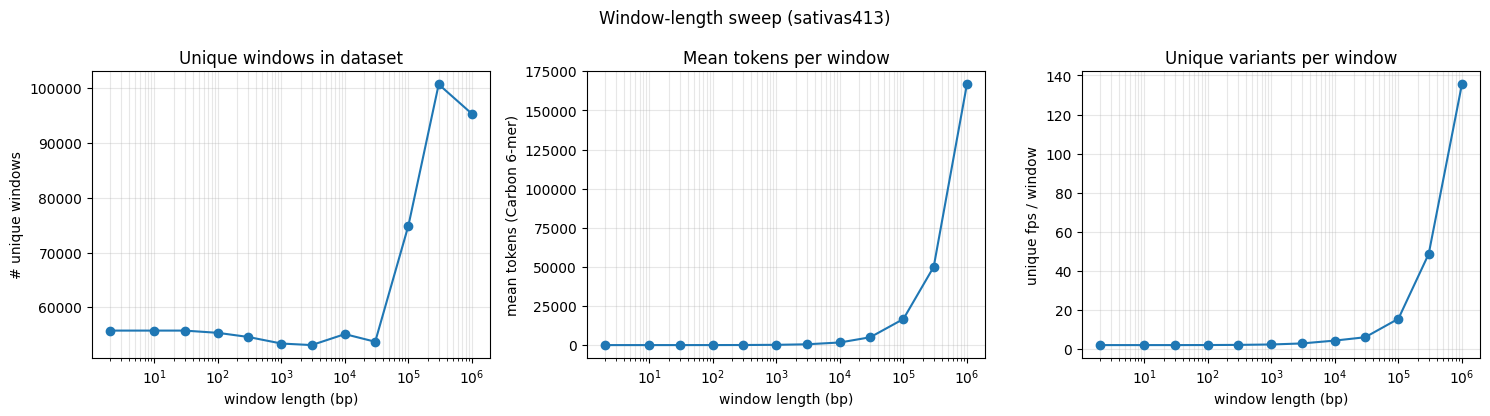

,length,half_window,n_windows,n_unique_windows,mean_tokens,variants_per_window
0,2,1,27881,55762,2.0,2.0000
1,10,5,27881,55762,3.0,2.0000
2,30,15,27881,55762,6.0,2.0000
3,100,50,27299,55351,18.0,2.0276
4,300,150,26012,54600,51.0,2.0990
5,1000,500,23138,53398,168.0,2.3078
6,3000,1500,18744,53115,501.0,2.8337
7,10000,5000,12807,55120,1668.0,4.3039
8,30000,15000,8928,53724,5001.0,6.0175
9,100000,50000,4842,74932,16668.0,15.4754


In [2]:
csv = REPO / "presentation" / "window_sweep.csv"
if not csv.exists():
    print(f"{csv} missing — run: python presentation/count_windows.py")
else:
    df = pd.read_csv(csv).sort_values("length")
    panels = [("n_unique_windows", "Unique windows in dataset", "# unique windows"),
              ("mean_tokens", "Mean tokens per window", "mean tokens (Carbon 6-mer)"),
              ("variants_per_window", "Unique variants per window", "unique fps / window")]
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
    for ax, (col, title, ylab) in zip(axes, panels):
        sub = df.dropna(subset=[col])
        ax.plot(sub["length"], sub[col], "o-")
        ax.set_xscale("log"); ax.set_xlabel("window length (bp)")
        ax.set_ylabel(ylab); ax.set_title(title); ax.grid(alpha=.3, which="both")
    fig.suptitle("Window-length sweep (sativas413)"); fig.tight_layout()
    fig.savefig(FIGS / "01_window_sweep.png", dpi=150); plt.show()
    display(df)


## 2. Effect of training diffs on MSE / PCC curves (train + val)

Compares the **variant** diff (absolute / centered / refdelta) at a fixed config
(mlp head, mean pool, warm-started standardizer) on the `carbon500m_hw500` cache,
reading the JSONL sidecars from the head sweep. Change `CFG` to compare a
different axis.


In [ ]:
# Discover the three variant runs at one fixed config. linear_mean_ws1 is the
# config present for all three variants (refdelta has only linear runs); switch
# to e.g. "mlp_mean_ws1_lr1e-3_wd1e-4_ep15" to compare the heads that exist.
CFG = "linear_mean_ws1_lr1e-3_wd1e-4_ep15"
CACHE_TAG = "sativas413_carbon500m_hw500"
runs = {}
for variant in ("absolute", "centered", "refdelta"):
    p = (REPO / "trained_heads" / "head_sweep" / variant /
         f"{CACHE_TAG}__{variant}_{CFG}" / "model.metrics.jsonl")
    if p.exists():
        runs[variant] = p
print("found runs:", list(runs))

if not runs:
    print("No metrics found — run train_pipeline/run_head_sweep.sh first.")
else:
    panels = [("train/mean_mse", "train MSE"), ("val/mean_mse", "val MSE"),
              ("train/mean_pcc", "train PCC"), ("val/mean_pcc", "val PCC")]
    fig, axes = plt.subplots(2, 2, figsize=(13, 9)); axes = axes.ravel()
    for label, path in runs.items():
        tr, va = load_metrics(path)
        for (key, title), ax in zip(panels, axes):
            rows = va if key.startswith("val/") else tr
            ax.plot(*series(rows, key), label=label)
            ax.set_title(title); ax.set_xlabel("step"); ax.grid(alpha=.3)
    axes[0].legend()
    fig.suptitle(f"Variant diff (absolute/centered/refdelta) — {CACHE_TAG}, {CFG}")
    fig.tight_layout(); fig.savefig(FIGS / "02_diff_curves.png", dpi=150); plt.show()


In [ ]:
# Per-trait val PCC for a chosen subset of traits.
TRAITS = ["Seed length", "Flowering time at Arkansas", "Amylose content"]
if runs:
    fig, axes = plt.subplots(1, len(TRAITS), figsize=(5*len(TRAITS), 4), squeeze=False)
    for j, trait in enumerate(TRAITS):
        ax = axes[0][j]
        for label, path in runs.items():
            _, va = load_metrics(path)
            ax.plot(*series(va, f"val/pcc/{trait}"), label=label)
        ax.set_title(f"val PCC — {trait}"); ax.set_xlabel("step"); ax.grid(alpha=.3)
    axes[0][0].legend()
    fig.tight_layout(); fig.savefig(FIGS / "02_per_trait_pcc.png", dpi=150); plt.show()


## 3. UMAP of per-sample embeddings across preprocessing options

Pools each available Carbon cache under two recipes (`sum+std`, `center+ln`) and
UMAPs the per-sample vectors, colored by inferred subpopulation. **Slow** (~a few
minutes; one UMAP per panel). Set `RECMAP` to fewer panels to speed up.


/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


panels: ['Carbon all / sum+std', 'Carbon all / center+ln', 'Carbon snp-only / sum+std', 'Carbon-VC all / sum+std']


/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


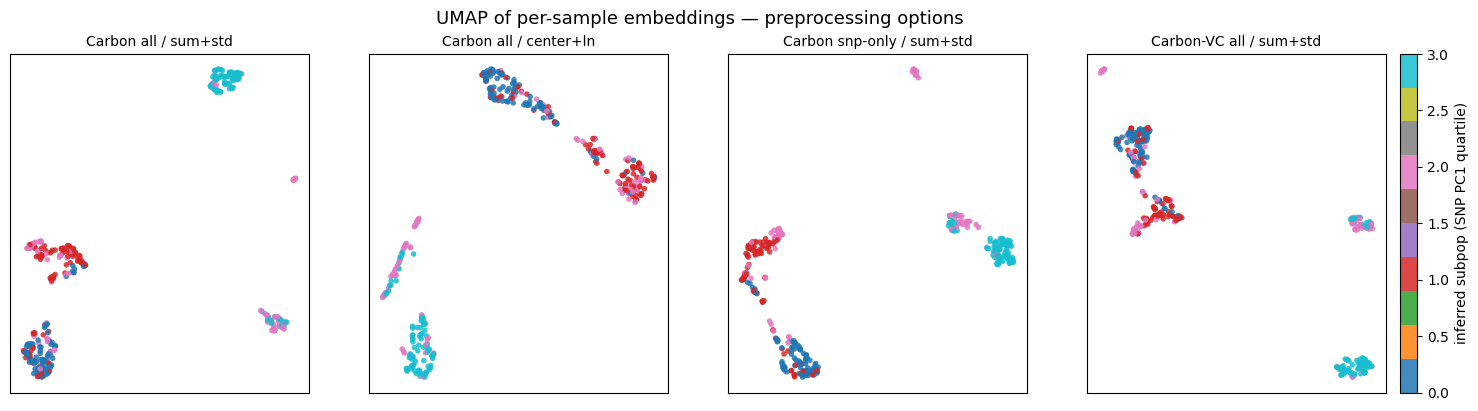

In [ ]:
import umap
from presentation.pool_cache import per_sample_matrix, subpop_labels

CK = REPO / "checkpoints" / "manual"
PANELS = [
    ("Carbon all / sum+std",      CK / "sativas413_carbon500m_hw500.ckpt.pt",          "sum_std"),
    ("Carbon all / center+ln",    CK / "sativas413_carbon500m_hw500.ckpt.pt",          "center_ln_mean"),
    ("Carbon snp-only / sum+std", CK / "sativas413_carbon500m_hw500_snponly.ckpt.pt",  "sum_std"),
    ("Carbon-VC all / sum+std",   CK / "sativas413_carbon500m_vc_hw500.ckpt.pt",       "sum_std"),
]
avail = [(t, c, r) for (t, c, r) in PANELS if c.exists()]
print("panels:", [t for t, _, _ in avail])

ncol = min(4, len(avail)); nrow = (len(avail) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6*ncol, 4.4*nrow), squeeze=False)
axes = axes.ravel(); sc = None
for ax, (title, cache, recipe) in zip(axes, avail):
    X, ids = per_sample_matrix(str(cache), recipe)
    coords = umap.UMAP(n_components=2, random_state=42,
                       n_neighbors=15, min_dist=0.05).fit_transform(X)
    pops = subpop_labels(ids)
    sc = ax.scatter(coords[:,0], coords[:,1], cmap="tab10",
                    vmin=0, vmax=int(pops.max()), s=16, alpha=.85, linewidths=0)
    ax.set_title(title, fontsize=10); ax.set_xticks([]); ax.set_yticks([])
for ax in axes[len(avail):]:
    ax.axis("off")
if sc is not None:
    fig.colorbar(sc, ax=axes.tolist(), label="inferred subpop (SNP PC1 quartile)",
                 fraction=0.025, pad=0.01)
fig.suptitle("UMAP of per-sample embeddings — preprocessing options", fontsize=13)
fig.savefig(FIGS / "03_umap_grid.png", dpi=150, bbox_inches="tight"); plt.show()


# 3.1

/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/local/scratch/andrew.dickson/20075530/ipykernel_2126960/235214478.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  sc = ax.scatter(coords[:,0], coords[:,1], cmap="tab10",
/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/local/scratch/andrew.dickson/20075530/ipykernel_2126960/235214478.py:32: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'vmin', 'vmax' will be ignored
  sc = ax.scatter(coords[:,0], coords[:,1], cmap="tab10",
/home/andrew.dickson/.conda/envs/svar/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by sett

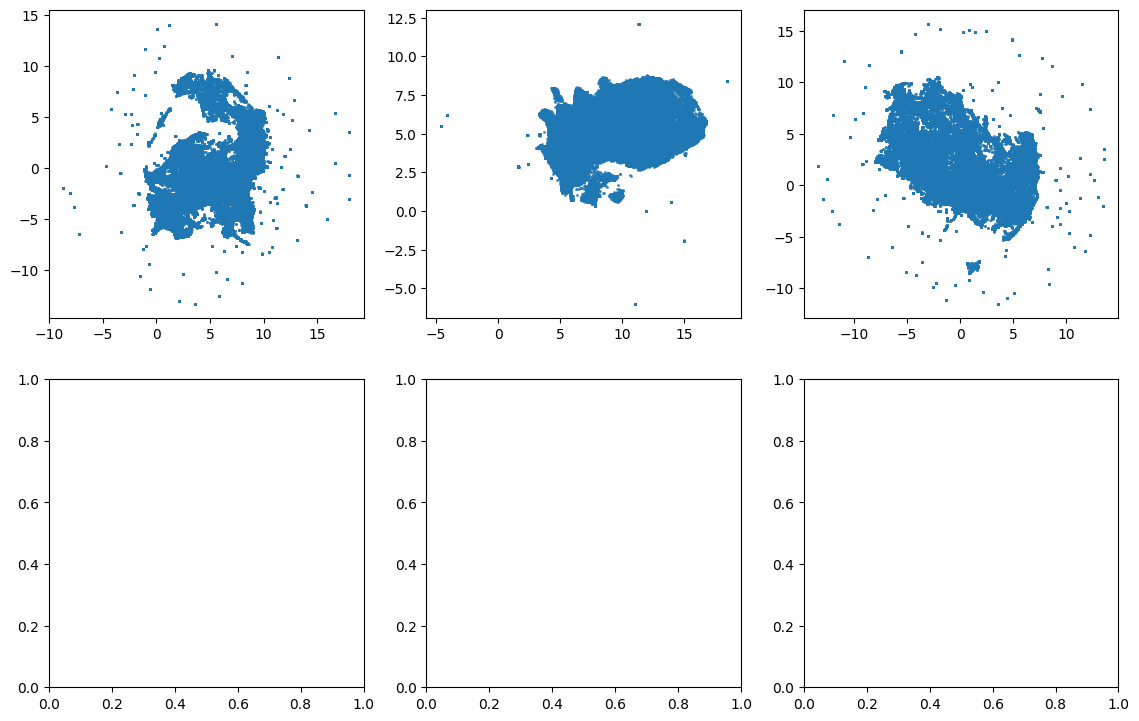

In [17]:
import umap
from presentation.pool_cache import per_sample_matrix, subpop_labels
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F

from crop_embed import FixedWindowEmbedder

CK = REPO / "checkpoints" / "manual"
ckpts = [CK / "sativas413_carbon500m_hw500.ckpt.pt", 
        CK / "sativas413_carbon500m_hw500_snponly.ckpt.pt", 
        CK / "sativas413_carbon500m_vc_hw500.ckpt.pt"]

ncol = min(4, len(ckpts)); nrow = (len(avail) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6*ncol, 4.4*nrow), squeeze=False)
axes = axes.ravel(); sc = None
umap_res = {}

import torch
for ax, cache_path in zip(axes, ckpts):
    payload = torch.load(cache_path, map_location="cpu", weights_only=False)
    sample_ids = payload.get("sample_ids")
    emb = FixedWindowEmbedder.from_file(cache_path)
    cache = emb.cache.float()             # (n_fps, D)
#     print(cache.shape)
    coords = umap.UMAP(n_components=2, random_state=42,
                       n_neighbors=15, min_dist=0.05).fit_transform(cache.numpy())
    pops = subpop_labels(ids)
    sc = ax.scatter(coords[:,0], coords[:,1], cmap="tab10",
                    vmin=0, vmax=int(pops.max()), s=4, alpha=.85, linewidths=0)
    umap_res[cache_path] = coords


In [ ]:
ncol = min(4, len(ckpts)); nrow = (len(avail) + ncol - 1) // ncol
fig, axes = plt.subplots(nrow, ncol, figsize=(4.6*ncol, 4.4*nrow), squeeze=False)
axes = axes.ravel(); sc = None
umap_res = {}

import torch
for ax, cache_path in zip(axes, ckpts):
    coords = umap_res[cache_path]
    pops = subpop_labels(ids)
    sc = ax.scatter(coords[:,0], coords[:,1], cmap="tab10",
                    vmin=0, vmax=int(pops.max()), s=1, alpha=.6, linewidths=0)
    umap_res[cache_path] = coords

In [16]:
fig.savefig(FIGS / "031_fp_umap_grid.png", dpi=150, bbox_inches="tight"); plt.show()


## 4. SNP-embedding degradation under the variant-cache approximation

Input: `presentation/vc_degradation.csv` (from
`python -m model_dev.compare_variant_cache_embeddings --csv-out ...`, GPU).


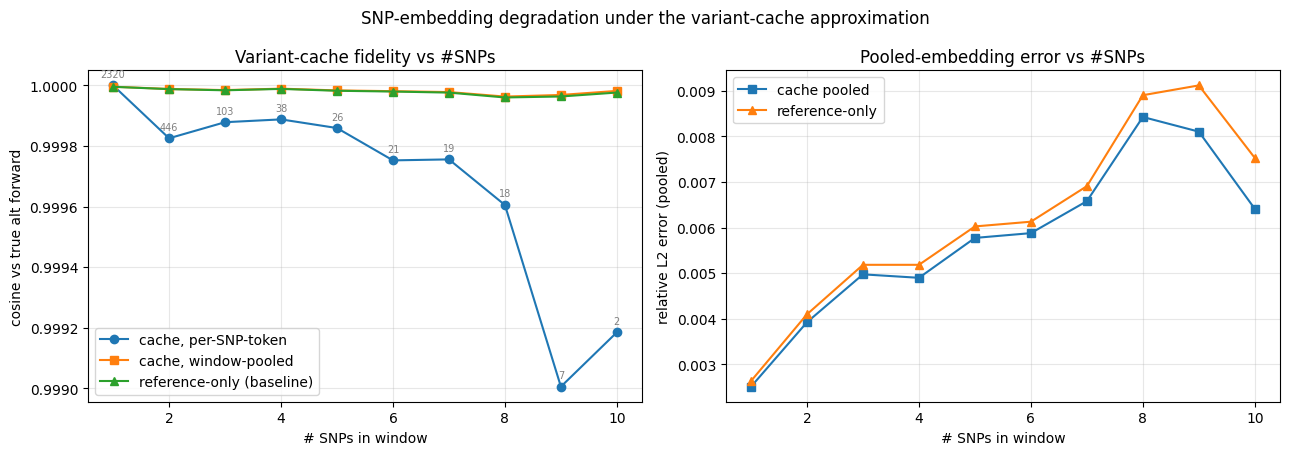

In [4]:
csv = REPO / "presentation" / "vc_degradation.csv"
if not csv.exists():
    print(f"{csv} missing — run compare_variant_cache_embeddings.py --csv-out (GPU).")
else:
    d = pd.read_csv(csv); d = d[d["n_snp"].between(1, 10)]
    n_per_bin = d.groupby("n_snp").size(); g = d.groupby("n_snp").mean(numeric_only=True)
    fig, (axc, axe) = plt.subplots(1, 2, figsize=(13, 4.6))
    axc.plot(g.index, g["var_cos"], "o-", label="cache, per-SNP-token")
    axc.plot(g.index, g["cache_pool_cos"], "s-", label="cache, window-pooled")
    axc.plot(g.index, g["ref_pool_cos"], "^-", label="reference-only (baseline)")
    axc.set_xlabel("# SNPs in window"); axc.set_ylabel("cosine vs true alt forward")
    axc.set_title("Variant-cache fidelity vs #SNPs"); axc.legend(); axc.grid(alpha=.3)
    for n, cnt in n_per_bin.items():
        axc.annotate(str(cnt), (n, g.loc[n, "var_cos"]), fontsize=7,
                     textcoords="offset points", xytext=(0, 6), ha="center", color="gray")
    axe.plot(g.index, g["cache_relerr"], "s-", label="cache pooled")
    axe.plot(g.index, g["ref_relerr"], "^-", label="reference-only")
    axe.set_xlabel("# SNPs in window"); axe.set_ylabel("relative L2 error (pooled)")
    axe.set_title("Pooled-embedding error vs #SNPs"); axe.legend(); axe.grid(alpha=.3)
    fig.suptitle("SNP-embedding degradation under the variant-cache approximation")
    fig.tight_layout(); fig.savefig(FIGS / "04_vc_degradation.png", dpi=150); plt.show()


## 5. Carbon AR fine-tune curves (variant cache, 90% train)

Input: the JSONL sidecar from `variant_ar/train.py` (`…/carbon_vc.metrics.jsonl`).
Log-likelihood on SNP tokens = −NLL.


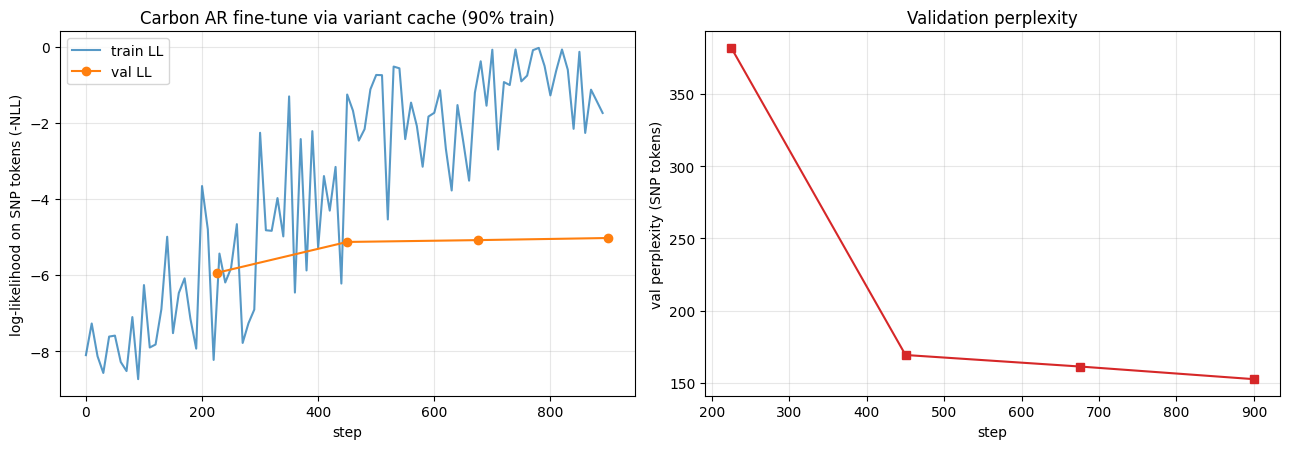

In [5]:
mpath = REPO / "checkpoints" / "variant_ar" / "carbon_vc.metrics.jsonl"
if not mpath.exists() or mpath.stat().st_size == 0:
    print(f"{mpath} not ready — run variant_ar/train.py --backend cache (GPU).")
else:
    tr, va = load_metrics(mpath)
    fig, (ax_ll, ax_ppl) = plt.subplots(1, 2, figsize=(13, 4.6))
    ax_ll.plot(*series(tr, "train/ll"), label="train LL", alpha=.75)
    ax_ll.plot(*series(va, "val/ll"), "o-", label="val LL")
    ax_ll.set_xlabel("step"); ax_ll.set_ylabel("log-likelihood on SNP tokens (-NLL)")
    ax_ll.set_title("Carbon AR fine-tune via variant cache (90% train)")
    ax_ll.legend(); ax_ll.grid(alpha=.3)
    xs, ys = series(va, "val/perplexity")
    ax_ppl.plot(xs, ys, "s-", color="tab:red")
    ax_ppl.set_xlabel("step"); ax_ppl.set_ylabel("val perplexity (SNP tokens)")
    ax_ppl.set_title("Validation perplexity"); ax_ppl.grid(alpha=.3)
    fig.tight_layout(); fig.savefig(FIGS / "05_ar_curves.png", dpi=150); plt.show()
